# L4a Advanced: First-Passage Exit Rules

A terminal rule checks the position once, at a scheduled exit date. A monitored rule checks the position after every lattice step and exits the first time a take-profit or stop-loss boundary is reached. These rules generally have different probabilities because the monitored rule depends on the path.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Propagate surviving probability:** Move forward only the probability mass for positions that have not already exited.
> - **Compute first-passage outcomes:** Find the probability of reaching the take-profit boundary first, reaching the stop-loss boundary first, or remaining open through the horizon.
> - **Explain path dependence:** Show why paths that share one terminal price node can have different monitored-exit outcomes.

Let's get started!
___

## Setup, Data, and Prerequisites

We use a constant-factor binomial lattice under the real-world probability measure. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for the binomial distribution, and [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures. This notebook defines its own functions, so no local source files are loaded.

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## 1. Define the monitored exit rule

Let the share price start at $S_0$. At each step it is multiplied by $u$ with probability $p$ or by $d$ with probability $1-p$. We monitor two price boundaries after every step:

- exit with a **take profit** when $S_{j,k}\ge U$;
- exit with a **stop loss** when $S_{j,k}\le L$;
- otherwise keep the position open, up to step $N$.

The boundary test is inclusive. A position exits as soon as its price equals or crosses a boundary.

In [3]:
S₀ = 100.0
u = 1.06
d = 0.97
p = 0.55
N = 12
L = 90.0
U = 115.0

@assert 0 < d < u
@assert 0 < p < 1
@assert L < S₀ < U
(S₀ = S₀, u = u, d = d, p = p, steps = N, stop_loss = L, take_profit = U)

(S₀ = 100.0, u = 1.06, d = 0.97, p = 0.55, steps = 12, stop_loss = 90.0, take_profit = 115.0)

___

## 2. Propagate only positions that remain open

Let $a_{j,k}$ denote the probability mass that reaches node $(j,k)$ at step $j$ without crossing either boundary earlier. From an open node, the up branch carries mass $p\,a_{j,k}$ and the down branch carries mass $(1-p)a_{j,k}$. At the destination node, we either absorb that mass at a boundary or store it as open mass for the next step.

This recursion keeps exactly the extra state needed by the monitored rule: whether the position is still open.

In [4]:
price_at(S₀::Real, u::Real, d::Real, j::Int, k::Int) = S₀ * u^k * d^(j-k)

function first_passage_binomial(S₀::Real, u::Real, d::Real, p::Real, N::Int; lower::Real, upper::Real)
    @assert 0 < d < u
    @assert 0 <= p <= 1
    @assert lower < S₀ < upper
    @assert N >= 1

    alive = [1.0]
    cumulative_lower = 0.0
    cumulative_upper = 0.0
    rows = NamedTuple[(
        step = 0, hit_lower_at_step = 0.0, hit_upper_at_step = 0.0,
        cumulative_lower = 0.0, cumulative_upper = 0.0, open_probability = 1.0,
    )]

    for j in 1:N
        next_alive = zeros(Float64, j + 1)
        lower_at_step = 0.0
        upper_at_step = 0.0

        for k_previous in 0:(j-1)
            open_mass = alive[k_previous + 1]
            for (k_new, branch_probability) in ((k_previous, 1-p), (k_previous + 1, p))
                branch_mass = open_mass * branch_probability
                destination_price = price_at(S₀, u, d, j, k_new)
                if destination_price <= lower
                    lower_at_step += branch_mass
                elseif destination_price >= upper
                    upper_at_step += branch_mass
                else
                    next_alive[k_new + 1] += branch_mass
                end
            end
        end

        cumulative_lower += lower_at_step
        cumulative_upper += upper_at_step
        open_probability = sum(next_alive)
        @assert isapprox(cumulative_lower + cumulative_upper + open_probability, 1.0; atol=1e-12)

        push!(rows, (
            step = j, hit_lower_at_step = lower_at_step, hit_upper_at_step = upper_at_step,
            cumulative_lower = cumulative_lower, cumulative_upper = cumulative_upper,
            open_probability = open_probability,
        ))
        alive = next_alive
    end

    return (
        summary = DataFrame(rows), alive = alive,
        hit_lower = cumulative_lower, hit_upper = cumulative_upper,
        still_open = sum(alive),
    )
end

first_passage_binomial (generic function with 1 method)

In [5]:
result = first_passage_binomial(S₀, u, d, p, N; lower=L, upper=U)
result.summary

Row,step,hit_lower_at_step,hit_upper_at_step,cumulative_lower,cumulative_upper,open_probability
,Int64,Float64,Float64,Float64,Float64,Float64
1,0,0.0,0.0,0.0,0.0,1.0
2,1,0.0,0.0,0.0,0.0,1.0
3,2,0.0,0.0,0.0,0.0,1.0
4,3,0.0,0.166375,0.0,0.166375,0.833625
5,4,0.0410062,0.224606,0.0410062,0.390981,0.568012
6,5,0.0,0.0,0.0410062,0.390981,0.568012
7,6,0.0,0.11118,0.0410062,0.502161,0.456832
8,7,0.0182683,0.133416,0.0592745,0.635577,0.305148
9,8,0.0,0.0,0.0592745,0.635577,0.305148


In [6]:
outcome_table = DataFrame(
    outcome = ["Take profit first", "Stop loss first", "Still open after N steps"],
    probability = [result.hit_upper, result.hit_lower, result.still_open],
)
@assert isapprox(sum(outcome_table.probability), 1.0; atol=1e-12)
outcome_table

Row,outcome,probability
,String,Float64
1,Take profit first,0.78836
2,Stop loss first,0.0684304
3,Still open after N steps,0.14321


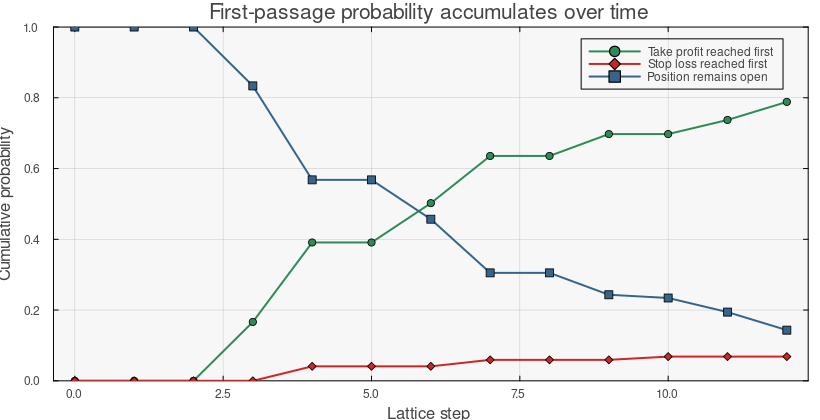

In [7]:
plot(
    result.summary.step, result.summary.cumulative_upper;
    marker=:circle, color=:seagreen4, label="Take profit reached first",
    xlabel="Lattice step", ylabel="Cumulative probability",
    title="First-passage probability accumulates over time",
    ylim=(0, 1), size=(820, 420),
)
plot!(result.summary.step, result.summary.cumulative_lower;
    marker=:diamond, color=:firebrick3, label="Stop loss reached first")
plot!(result.summary.step, result.summary.open_probability;
    marker=:square, color=:steelblue4, label="Position remains open")

___

## 3. Compare first passage with a terminal-only calculation

A terminal-only rule asks whether $S_{N,K_N}\ge U$ at step $N$. It ignores any earlier visit to $U$. To make a clean comparison, first remove the stop-loss and monitor only the upper boundary. The probability of reaching $U$ by step $N$ must then be at least as large as the probability of finishing above $U$: a path can reach the boundary and later fall below it. With both boundaries active, a path may reach the stop-loss first, so this inequality need not hold.

In [8]:
function terminal_upper_probability(S₀::Real, u::Real, d::Real, p::Real, N::Int, upper::Real)
    distribution = Binomial(N, p)
    return sum(pdf(distribution, k) for k in 0:N if price_at(S₀, u, d, N, k) >= upper)
end

terminal_probability = terminal_upper_probability(S₀, u, d, p, N, U)
upper_only = first_passage_binomial(S₀, u, d, p, N; lower=0.0, upper=U)
comparison = DataFrame(
    rule = ["Terminal price at or above U", "Upper boundary reached by N; no stop loss"],
    probability = [terminal_probability, upper_only.hit_upper],
)
@assert upper_only.hit_upper + 1e-12 >= terminal_probability
comparison

Row,rule,probability
,String,Float64
1,Terminal price at or above U,0.739315
2,Upper boundary reached by N; no stop loss,0.798494


___

## 4. One terminal node can contain different exit histories

Recombination merges paths with the same up-move count because they share a terminal price. A monitored rule cannot discard the earlier path. We enumerate the short path histories here only to expose that information loss; the absorbing recursion above is the efficient calculation.

In [9]:
function enumerate_exit_histories(S₀::Real, u::Real, d::Real, N::Int; lower::Real, upper::Real)
    rows = NamedTuple[]
    for moves in Iterators.product(fill((:D, :U), N)...)
        price = float(S₀)
        first_exit = :none
        first_exit_step = 0
        for (step, move) in enumerate(moves)
            price *= move == :U ? u : d
            if first_exit == :none && price <= lower
                first_exit = :stop_loss
                first_exit_step = step
            elseif first_exit == :none && price >= upper
                first_exit = :take_profit
                first_exit_step = step
            end
        end
        push!(rows, (
            path = join(string.(moves)), up_moves = count(==(:U), moves),
            terminal_price = price, first_exit = first_exit, first_exit_step = first_exit_step,
        ))
    end
    return DataFrame(rows)
end

histories = enumerate_exit_histories(S₀, u, d, N; lower=L, upper=U)
node_mix = combine(
    groupby(histories, :up_moves),
    :terminal_price => first => :terminal_price,
    :first_exit => (x -> length(unique(x))) => :number_of_exit_outcomes,
    :first_exit => (x -> join(sort(string.(unique(x))), ", ")) => :exit_outcomes,
)
mixed_nodes = node_mix[node_mix.number_of_exit_outcomes .> 1, :]
@assert nrow(mixed_nodes) > 0
mixed_nodes

Row,up_moves,terminal_price,number_of_exit_outcomes,exit_outcomes
,Int64,Float64,Int64,String
1,3,90.5447,3,"none, stop_loss, take_profit"
2,4,98.9458,3,"none, stop_loss, take_profit"
3,5,108.126,3,"none, stop_loss, take_profit"
4,6,118.159,2,"stop_loss, take_profit"
5,7,129.122,2,"stop_loss, take_profit"
6,8,141.102,2,"stop_loss, take_profit"


The table identifies terminal nodes that merge paths with different monitored-exit outcomes. Price and up-move count are sufficient for a terminal rule, but not for a first-passage rule. The state must also record whether the position has already exited.

For more complicated execution rules, the state may need to record the exit side, exit time, or other path information.

___

## Summary

This notebook replaced a terminal-node calculation with an absorbing probability recursion whose state distinguishes positions that remain open from positions that have already crossed a boundary.

> __Key Takeaways:__
>
> - **Terminal and monitored rules answer different questions:** Ending above a boundary is not the same event as reaching that boundary at any earlier time.
> - **Absorption prevents double counting:** Once probability mass exits through one boundary, it is not propagated again.
> - **Path-dependent rules require additional state:** A terminal price node alone does not reveal whether a take-profit or stop-loss boundary was crossed earlier.

The same recursion extends to time-dependent boundaries and other discrete monitored-exit rules.

___

## Disclaimer and Risks

This notebook is for instruction only. Boundary probabilities depend on the lattice parameters and on the assumed monitoring and execution rules. A real stop or limit order need not execute at its trigger price. This material is not investment or trading advice.

___